In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

In [3]:
df_clean = pd.read_csv('../../dataset/sayur_buah_bersih.csv')

print(f"Shape dataset: {df_clean.shape}")
df_clean.head(10)

Shape dataset: (3723, 6)


,nama_item,jenis_item,lokasi_penyimpanan,hari_sejak_pembelian,sisa_hari,label
0,Mangga,Buah,Pembeku,0,33,Matang
1,Timun,Sayur,Suhu Ruang,2,1,Busuk
2,Tomat,Sayur,Pendingin,0,2,Busuk
3,Apel,Buah,Suhu Ruang,4,16,Mentah
4,Tomat,Sayur,Suhu Ruang,1,0,Busuk
5,Mangga,Buah,Pendingin,0,3,Terlalu Matang
6,Anggur,Buah,Pembeku,2,37,Mentah
7,Cabe,Sayur,Pembeku,1,7,Busuk
8,Mangga,Buah,Pembeku,3,14,Terlalu Matang
9,Pisang,Buah,Suhu Ruang,0,0,Busuk


In [4]:
print(list(df_clean.columns))

['nama_item', 'jenis_item', 'lokasi_penyimpanan', 'hari_sejak_pembelian', 'sisa_hari', 'label']


In [5]:
df_clean.duplicated().sum()

1676

In [6]:
for col in df_clean.columns:
    print(f"\nKolom: {col}")
    print(df_clean[col].unique())


Kolom: nama_item
['Mangga' 'Timun' 'Tomat' 'Apel' 'Anggur' 'Cabe' 'Pisang' 'Kentang'
 'Wortel' 'Jeruk']

Kolom: jenis_item
['Buah' 'Sayur']

Kolom: lokasi_penyimpanan
['Pembeku' 'Suhu Ruang' 'Pendingin']

Kolom: hari_sejak_pembelian
[0 2 4 1 3 6 5]

Kolom: sisa_hari
[33  1  2 16  0  3 37  7 14 30 12 15 10  8 11 31  4 13 17  5  9 19 29 34
 38 24 20 22 35 26 36 18  6 25 27 21 28 40 23 39 41 32 42]

Kolom: label
['Matang' 'Busuk' 'Mentah' 'Terlalu Matang' 'Segar']


In [7]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3723 entries, 0 to 3722
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   nama_item             3723 non-null   object
 1   jenis_item            3723 non-null   object
 2   lokasi_penyimpanan    3723 non-null   object
 3   hari_sejak_pembelian  3723 non-null   int64 
 4   sisa_hari             3723 non-null   int64 
 5   label                 3723 non-null   object
dtypes: int64(2), object(4)
memory usage: 174.6+ KB


In [8]:
df_clean.isna().sum()

nama_item               0
jenis_item              0
lokasi_penyimpanan      0
hari_sejak_pembelian    0
sisa_hari               0
label                   0
dtype: int64

In [9]:
df_clean['hari_sejak_pembelian'].describe()

count    3723.000000
mean        1.995165
std         1.785811
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         6.000000
Name: hari_sejak_pembelian, dtype: float64

In [10]:
df_clean['hari_sejak_pembelian'] = (
    df_clean.groupby('jenis_item')['hari_sejak_pembelian']
    .transform(lambda x: x.fillna(x.median()))
)

In [11]:
df_clean.isna().sum()

nama_item               0
jenis_item              0
lokasi_penyimpanan      0
hari_sejak_pembelian    0
sisa_hari               0
label                   0
dtype: int64

In [12]:
for col in df_clean.columns:
    print(f"\nKolom: {col}")
    print(df_clean[col].unique())


Kolom: nama_item
['Mangga' 'Timun' 'Tomat' 'Apel' 'Anggur' 'Cabe' 'Pisang' 'Kentang'
 'Wortel' 'Jeruk']

Kolom: jenis_item
['Buah' 'Sayur']

Kolom: lokasi_penyimpanan
['Pembeku' 'Suhu Ruang' 'Pendingin']

Kolom: hari_sejak_pembelian
[0 2 4 1 3 6 5]

Kolom: sisa_hari
[33  1  2 16  0  3 37  7 14 30 12 15 10  8 11 31  4 13 17  5  9 19 29 34
 38 24 20 22 35 26 36 18  6 25 27 21 28 40 23 39 41 32 42]

Kolom: label
['Matang' 'Busuk' 'Mentah' 'Terlalu Matang' 'Segar']


### Komposisi  dan Distribusi Inventory

#### 1. Jenis item apa yang paling mendominasi inventori?

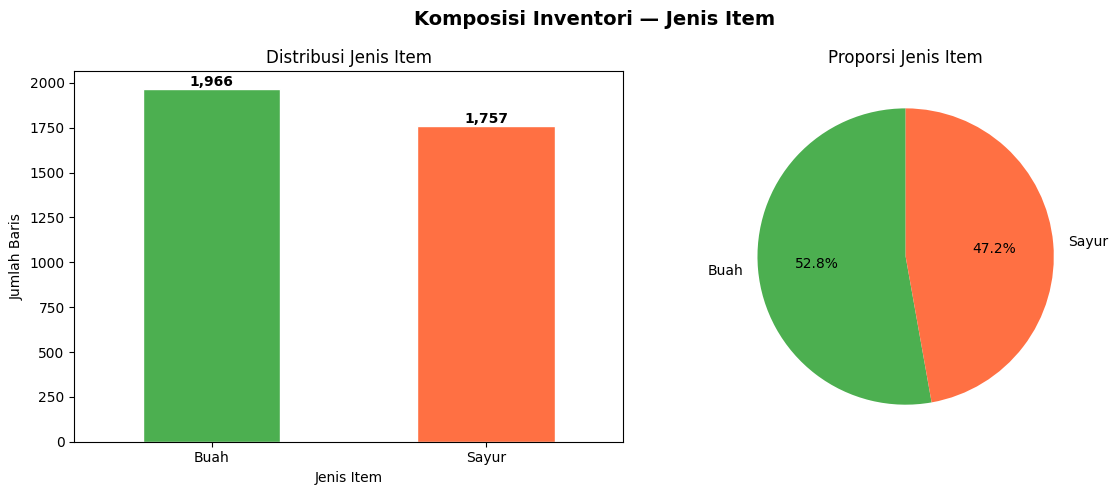

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df_clean['jenis_item'].value_counts()

# Bar chart
counts.plot(
    kind='bar',
    ax=axes[0],
    color=['#4CAF50', '#FF7043'],
    edgecolor='white',
    width=0.5
)
axes[0].set(
    title='Distribusi Jenis Item',
    xlabel='Jenis Item',
    ylabel='Jumlah Baris'
)
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# Pie chart
axes[1].pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4CAF50', '#FF7043']
)
axes[1].set_title('Proporsi Jenis Item')
plt.suptitle(
    'Komposisi Inventori — Jenis Item',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

#### 2. Bagaimana distribusi barang berdasarkan lokasi penyimpanan?


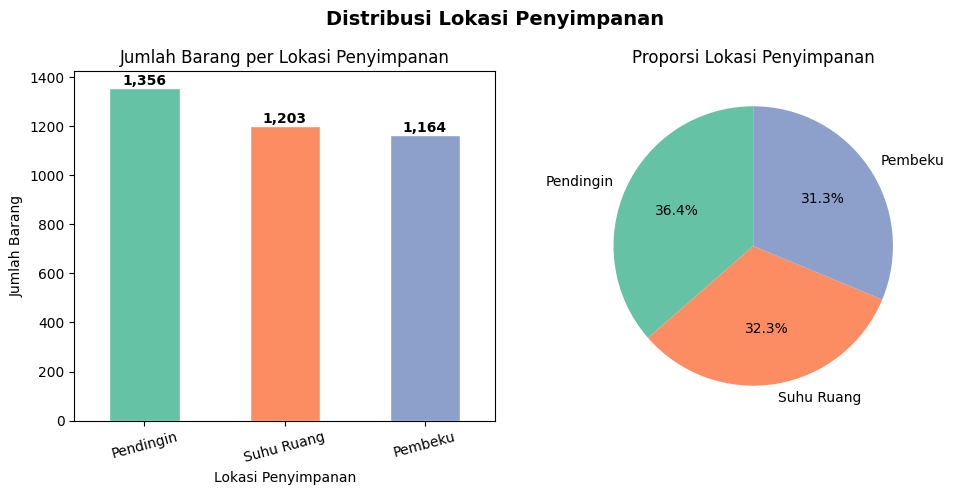

In [14]:
storage_counts = df_clean['lokasi_penyimpanan'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Bar chart
storage_counts.plot(
    kind='bar',
    ax=axes[0],
    color=sns.color_palette('Set2', 3),
    edgecolor='white',
    width=0.5
)
axes[0].set(
    title='Jumlah Barang per Lokasi Penyimpanan',
    xlabel='Lokasi Penyimpanan',
    ylabel='Jumlah Barang'
)
axes[0].tick_params(axis='x', rotation=15)

for p in axes[0].patches:
    axes[0].annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# Pie chart
axes[1].pie(
    storage_counts,
    labels=storage_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2', 3)
)
axes[1].set_title('Proporsi Lokasi Penyimpanan')
plt.suptitle(
    'Distribusi Lokasi Penyimpanan',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

#### 3. Berapa banyak item unik yang dikelola per kategori?

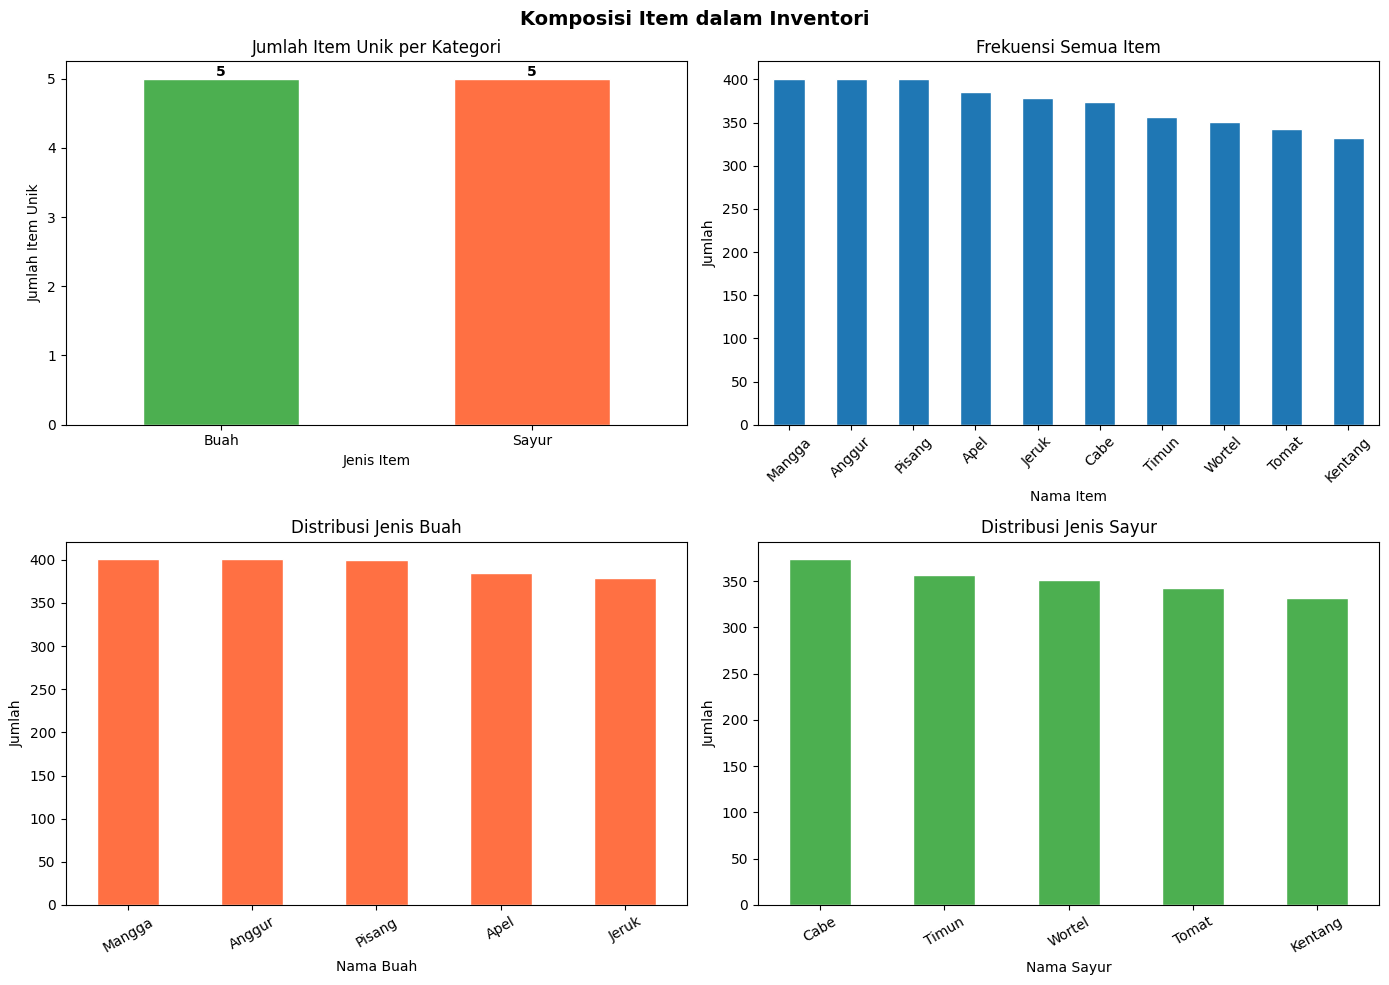

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Jumlah item unik per kategori
unique_items = (
    df_clean.groupby('jenis_item')['nama_item']
    .nunique()
    .sort_values(ascending=False)
)

unique_items.plot(
    kind='bar',
    ax=axes[0,0],
    color=['#4CAF50', '#FF7043'],
    edgecolor='white',
    width=0.5
)

axes[0,0].set(
    title='Jumlah Item Unik per Kategori',
    xlabel='Jenis Item',
    ylabel='Jumlah Item Unik'
)

axes[0,0].tick_params(axis='x', rotation=0)

for p in axes[0,0].patches:
    axes[0,0].annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# Distribusi semua item
all_counts = df_clean['nama_item'].value_counts()

all_counts.plot(
    kind='bar',
    ax=axes[0,1],
    edgecolor='white'
)

axes[0,1].set(
    title='Frekuensi Semua Item',
    xlabel='Nama Item',
    ylabel='Jumlah'
)

axes[0,1].tick_params(axis='x', rotation=45)

# Distribusi buah
buah_counts = (
    df_clean[df_clean['jenis_item'] == 'Buah']['nama_item']
    .value_counts()
)

buah_counts.plot(
    kind='bar',
    ax=axes[1,0],
    color='#FF7043',
    edgecolor='white'
)

axes[1,0].set(
    title='Distribusi Jenis Buah',
    xlabel='Nama Buah',
    ylabel='Jumlah'
)

axes[1,0].tick_params(axis='x', rotation=30)

# Distribusi sayur
sayur_counts = (
    df_clean[df_clean['jenis_item'] == 'Sayur']['nama_item']
    .value_counts()
)

sayur_counts.plot(
    kind='bar',
    ax=axes[1,1],
    color='#4CAF50',
    edgecolor='white'
)

axes[1,1].set(
    title='Distribusi Jenis Sayur',
    xlabel='Nama Sayur',
    ylabel='Jumlah'
)

axes[1,1].tick_params(axis='x', rotation=30)

plt.suptitle(
    'Komposisi Item dalam Inventori',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### Analisis Masa Simpan & Kesegaran

#### 1. Berapa rata-rata `hari_sejak_pembelian` untuk setiap kategori barang?

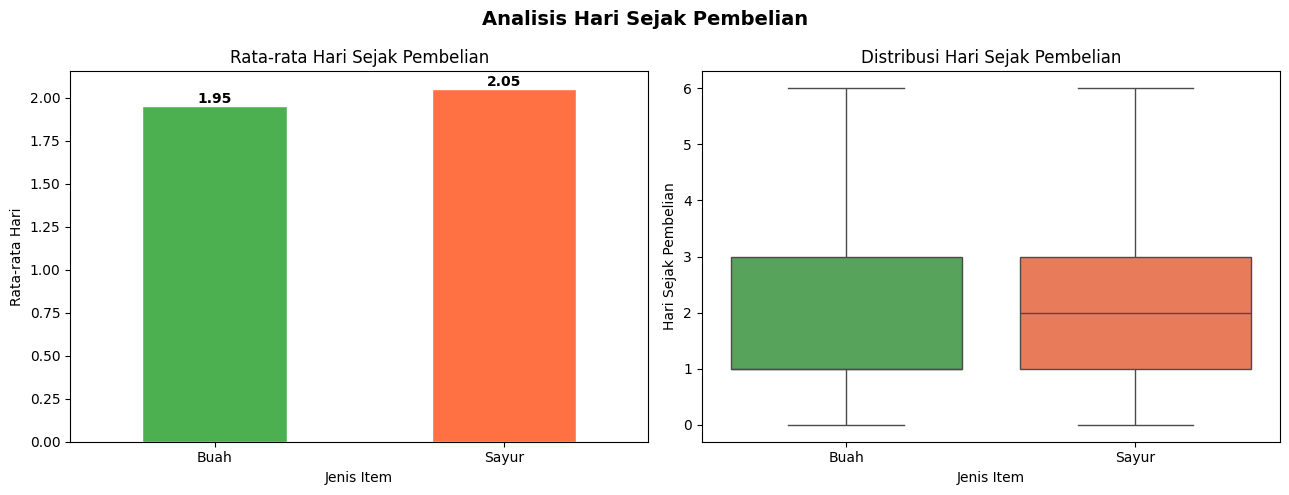

In [16]:
avg_days = (
    df_clean.groupby('jenis_item')['hari_sejak_pembelian']
    .agg(['mean', 'median', 'std'])
    .round(2)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart rata-rata
avg_days['mean'].plot(
    kind='bar',
    ax=axes[0],
    color=['#4CAF50', '#FF7043'],
    edgecolor='white',
    width=0.5
)

axes[0].set(
    title='Rata-rata Hari Sejak Pembelian',
    xlabel='Jenis Item',
    ylabel='Rata-rata Hari'
)

axes[0].tick_params(axis='x', rotation=0)

for p in axes[0].patches:
    axes[0].annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# Boxplot distribusi
sns.boxplot(
    data=df_clean,
    x='jenis_item',
    y='hari_sejak_pembelian',
    ax=axes[1],
    palette=['#4CAF50', '#FF7043']
)

axes[1].set(
    title='Distribusi Hari Sejak Pembelian',
    xlabel='Jenis Item',
    ylabel='Hari Sejak Pembelian'
)

plt.suptitle(
    'Analisis Hari Sejak Pembelian',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

#### 2. Bagaimana distribusi label kondisi (Segar/Busuk/dll) per jenis item?

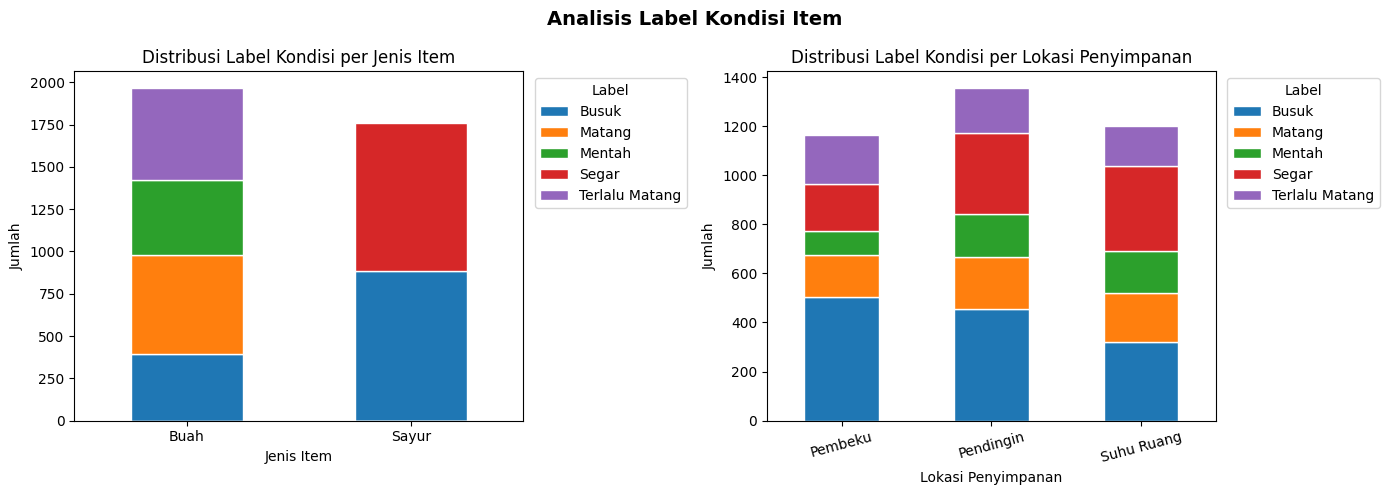

In [17]:
label_dist = (
    df_clean.groupby(['jenis_item', 'label'])
    .size()
    .unstack(fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi label per jenis item
label_dist.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    edgecolor='white'
)

axes[0].set(
    title='Distribusi Label Kondisi per Jenis Item',
    xlabel='Jenis Item',
    ylabel='Jumlah'
)

axes[0].tick_params(axis='x', rotation=0)

axes[0].legend(
    title='Label',
    bbox_to_anchor=(1.01, 1),
    loc='upper left'
)

# Distribusi label per lokasi penyimpanan
label_storage = (
    df_clean.groupby(['lokasi_penyimpanan', 'label'])
    .size()
    .unstack(fill_value=0)
)

label_storage.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    edgecolor='white'
)

axes[1].set(
    title='Distribusi Label Kondisi per Lokasi Penyimpanan',
    xlabel='Lokasi Penyimpanan',
    ylabel='Jumlah'
)

axes[1].tick_params(axis='x', rotation=15)

axes[1].legend(
    title='Label',
    bbox_to_anchor=(1.01, 1),
    loc='upper left'
)

plt.suptitle(
    'Analisis Label Kondisi Item',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

#### 3. "Berdasarkan sisa_hari, berapa persentase buah yang masuk kategori Busuk, Terlalu Matang, Matang, dan Mentah?"

Jumlah tiap kategori:
kategori_buah
Busuk             1017
Matang             958
Terlalu Matang     765
Lainnya            681
Mentah             302
Name: count, dtype: int64

Persentase tiap kategori:
kategori_buah
Busuk             27.316680
Matang            25.731937
Terlalu Matang    20.547945
Lainnya           18.291700
Mentah             8.111738
Name: proportion, dtype: float64


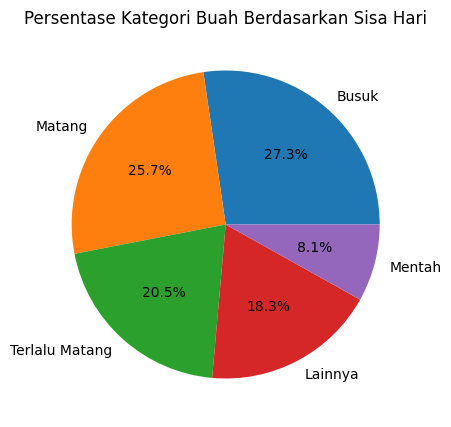

In [ ]:
# Fungsi kategorisasi
def kategori_buah(sisa_hari):
    if 0 <= sisa_hari <= 2:
        return 'Busuk'
    elif 4 <= sisa_hari <= 8:
        return 'Terlalu Matang'
    elif 10 <= sisa_hari <= 20:
        return 'Matang'
    elif 14 <= sisa_hari <= 28:
        return 'Mentah'
    else:
        return 'Lainnya'

# Tambahkan kolom kategori
df_clean['kategori_buah'] = df_clean['sisa_hari'].apply(kategori_buah)

# Hitung jumlah tiap kategori
kategori_count = df_clean['kategori_buah'].value_counts()

# Hitung persentase
kategori_percent = (
    df_clean['kategori_buah']
    .value_counts(normalize=True) * 100
)

# Print hasil
print("Jumlah tiap kategori:")
print(kategori_count)

print("\nPersentase tiap kategori:")
print(kategori_percent)

# Pie chart
plt.figure(figsize=(5,5))

plt.pie(
    kategori_count,
    labels=kategori_count.index,
    autopct='%1.1f%%'
)

plt.title('Persentase Kategori Buah Berdasarkan Sisa Hari')
plt.show()

### Analisis Efektivitas Penyimpanan

#### 1. Lokasi penyimpanan mana yang paling efektif menjaga sisa umur simpan? 

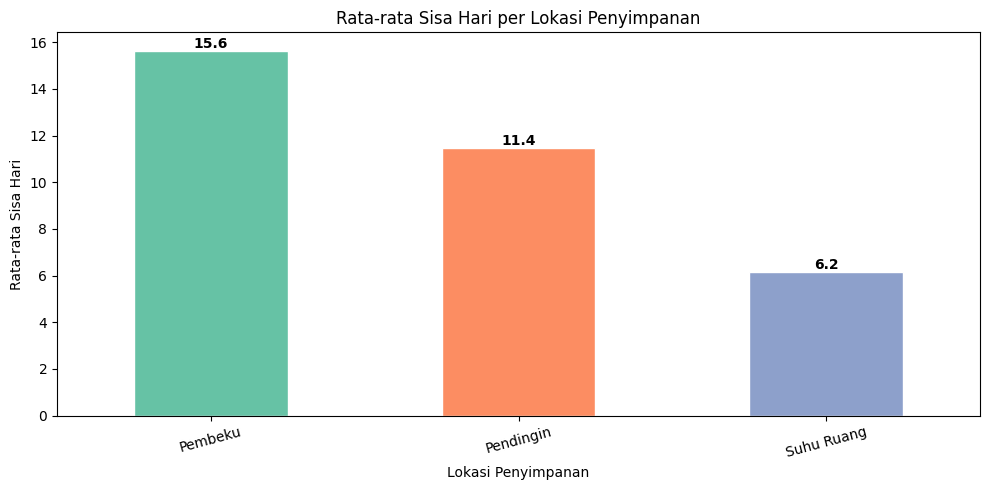

In [27]:
storage_stats = (
    df_clean.groupby('lokasi_penyimpanan')['sisa_hari']
    .agg(['mean', 'median', 'std'])
    .round(2)
    .sort_values('mean', ascending=False)
)

plt.figure(figsize=(10,5))

storage_stats['mean'].plot(
    kind='bar',
    color=sns.color_palette('Set2', len(storage_stats)),
    edgecolor='white',
    width=0.5
)

plt.title('Rata-rata Sisa Hari per Lokasi Penyimpanan')
plt.xlabel('Lokasi Penyimpanan')
plt.ylabel('Rata-rata Sisa Hari')

plt.xticks(rotation=15)

for p in plt.gca().patches:
    plt.gca().annotate(
        f'{p.get_height():.1f}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

#### 2. Apakah ada perbedaan signifikan sisa hari antar lokasi penyimpanan?

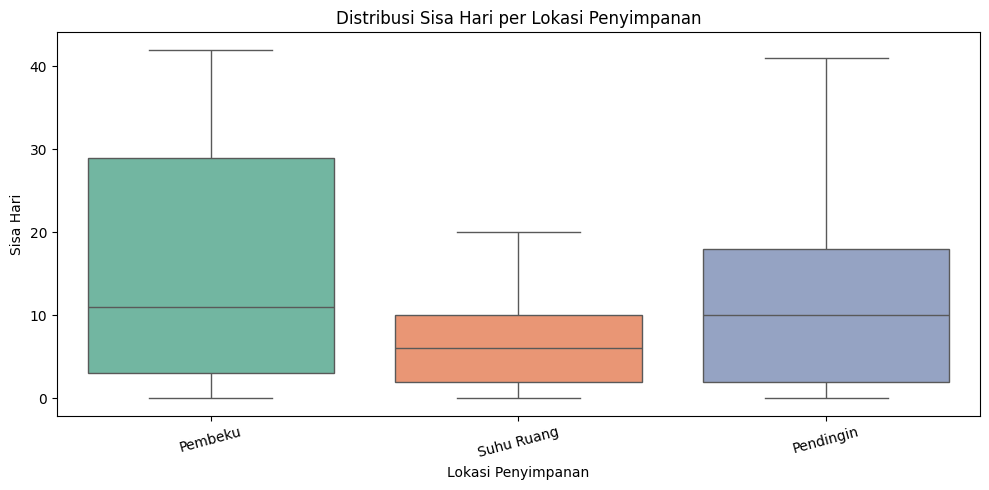

In [28]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_clean,
    x='lokasi_penyimpanan',
    y='sisa_hari',
    palette='Set2'
)

plt.title('Distribusi Sisa Hari per Lokasi Penyimpanan')
plt.xlabel('Lokasi Penyimpanan')
plt.ylabel('Sisa Hari')

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# ANOVA test
groups = [
    group['sisa_hari'].values
    for _, group in df_clean.groupby('lokasi_penyimpanan')
]

f_stat, p_val = stats.f_oneway(*groups)

#### 3. Bagaimana distribusi jenis item di setiap lokasi penyimpanan?

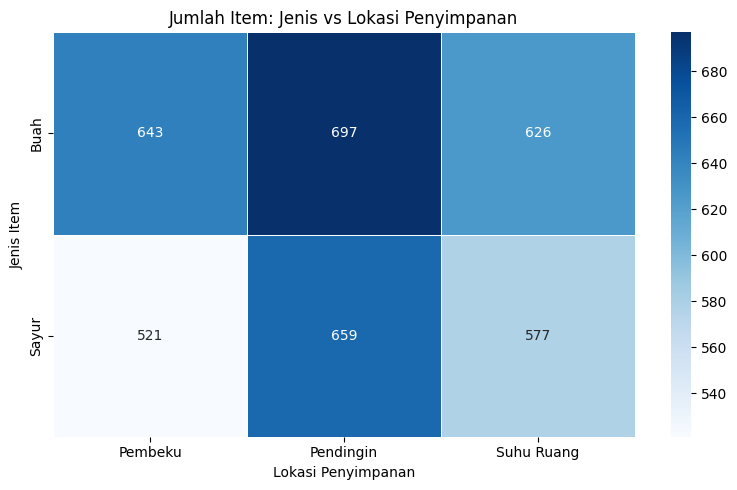

In [29]:
cross_tab = pd.crosstab(
    df_clean['jenis_item'],
    df_clean['lokasi_penyimpanan']
)

plt.figure(figsize=(8,5))

sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5
)

plt.title('Jumlah Item: Jenis vs Lokasi Penyimpanan')
plt.xlabel('Lokasi Penyimpanan')
plt.ylabel('Jenis Item')

plt.tight_layout()
plt.show()

#### 4. Apakah ada kombinasi jenis item & lokasi yang tampak tidak sesuai?

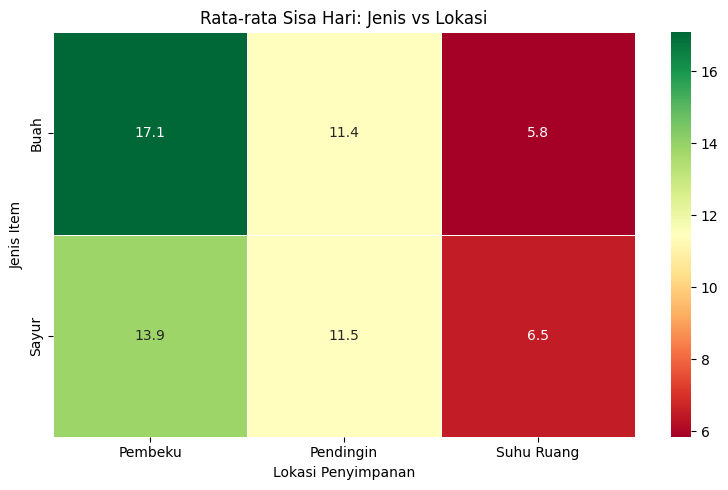

In [30]:
pivot = df_clean.pivot_table(
    values='sisa_hari',
    index='jenis_item',
    columns='lokasi_penyimpanan',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5
)

plt.title('Rata-rata Sisa Hari: Jenis vs Lokasi')
plt.xlabel('Lokasi Penyimpanan')
plt.ylabel('Jenis Item')

plt.tight_layout()
plt.show()

### Food Waste Risk Analysis

#### 1. Bagaimana distribusi barang persediaan berdasarkan kondisi kesegarannya (segar, mentah, matang, terlalu matang, dan busuk) menurut jenis barang?

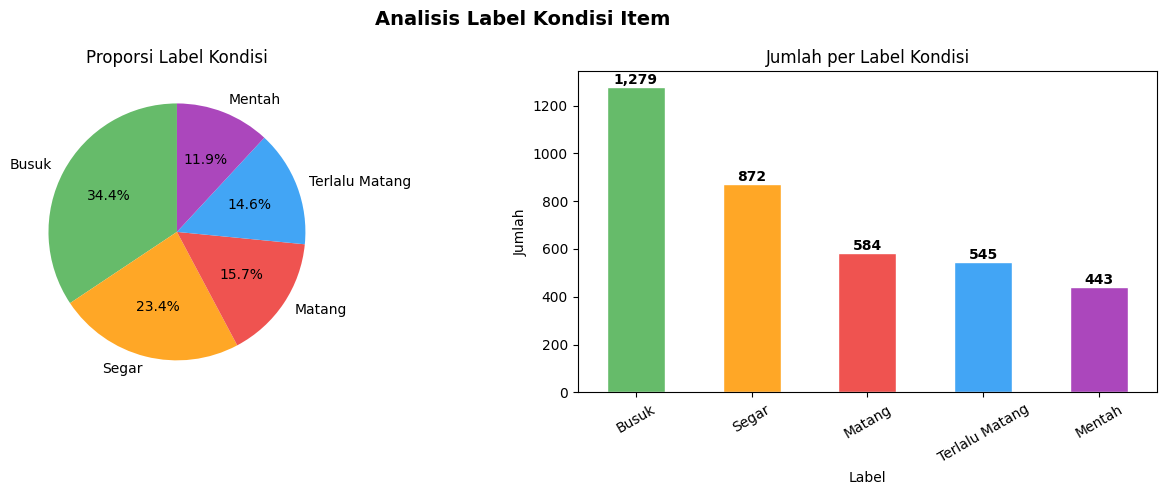

In [32]:
label_counts = df_clean['label'].value_counts()
label_pct = (label_counts / len(df_clean) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#66BB6A', '#FFA726', '#EF5350', '#42A5F5', '#AB47BC']

# Pie chart
axes[0].pie(
    label_counts,
    labels=label_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors[:len(label_counts)]
)

axes[0].set_title('Proporsi Label Kondisi')

# Bar chart
label_counts.plot(
    kind='bar',
    ax=axes[1],
    color=colors[:len(label_counts)],
    edgecolor='white'
)

axes[1].set(
    title='Jumlah per Label Kondisi',
    xlabel='Label',
    ylabel='Jumlah'
)

axes[1].tick_params(axis='x', rotation=30)

for p in axes[1].patches:
    axes[1].annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.suptitle(
    'Analisis Label Kondisi Item',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

#### 2. Kombinasi jenis item & lokasi penyimpanan mana yang paling berisiko food waste?

Kombinasi Jenis Item & Lokasi Penyimpanan Berisiko Tinggi (Sisa < 3 Hari):
jenis_item lokasi_penyimpanan  jumlah_kritis
     Sayur          Pendingin            246
     Sayur         Suhu Ruang            231
      Buah         Suhu Ruang            167
      Buah            Pembeku            130
      Buah          Pendingin            129
     Sayur            Pembeku            114


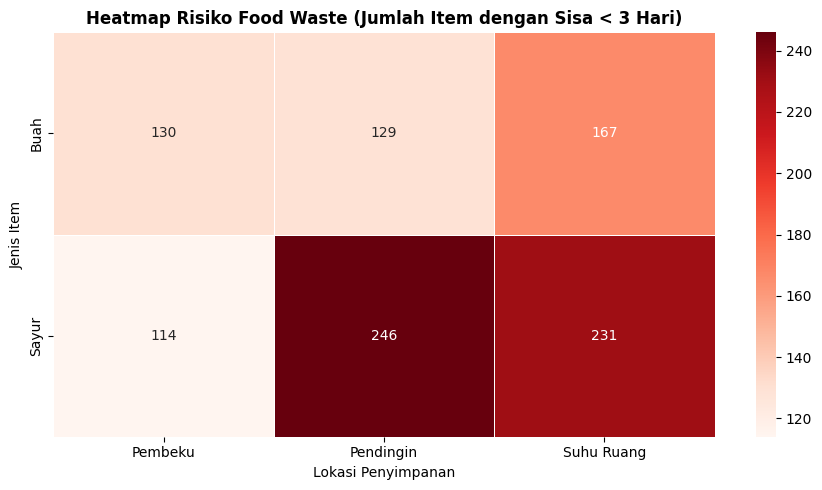

In [24]:
critical_df = df_clean[df_clean['sisa_hari'] < 3]
risk_combo = (
    critical_df.groupby(['jenis_item', 'lokasi_penyimpanan'])
    .size()
    .reset_index(name='jumlah_kritis')
    .sort_values('jumlah_kritis', ascending=False)
)

print("Kombinasi Jenis Item & Lokasi Penyimpanan Berisiko Tinggi (Sisa < 3 Hari):")
print(risk_combo.to_string(index=False))

heatmap_risk = pd.pivot_table(
    critical_df, values='sisa_hari',
    index='jenis_item', columns='lokasi_penyimpanan', aggfunc='count'
).fillna(0)

plt.figure(figsize=(9, 5))
sns.heatmap(heatmap_risk, annot=True, fmt='.0f', cmap='Reds', linewidths=0.5)
plt.title('Heatmap Risiko Food Waste (Jumlah Item dengan Sisa < 3 Hari)', fontweight='bold')
plt.xlabel('Lokasi Penyimpanan')
plt.ylabel('Jenis Item')
plt.tight_layout()
plt.show()

#### 3. Item nama mana yang memiliki rata-rata sisa hari paling rendah?

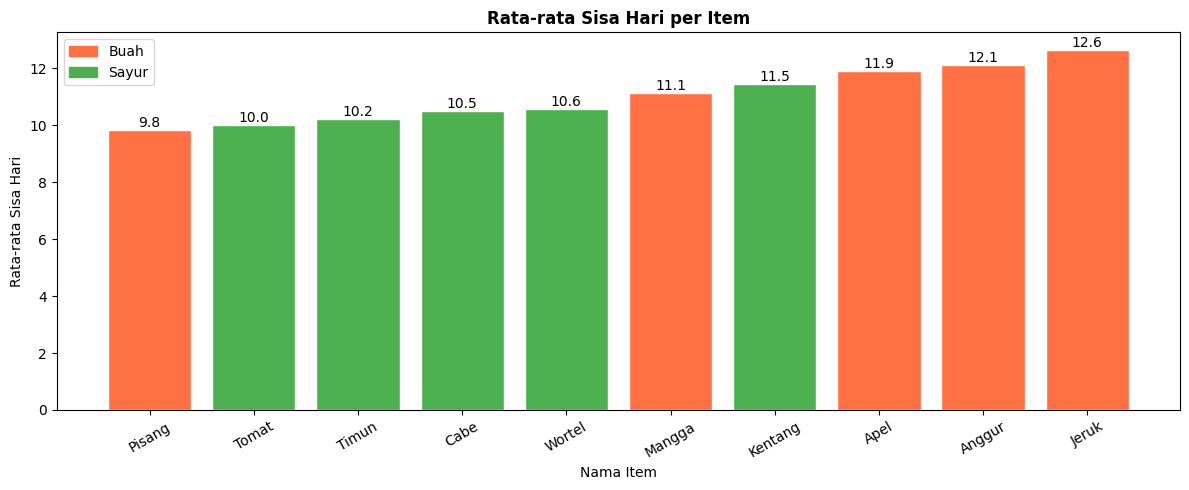

In [25]:
avg_sisa_item = (
    df_clean.groupby(['nama_item', 'jenis_item'])['sisa_hari']
    .mean()
    .reset_index()
    .sort_values('sisa_hari')
)

plt.figure(figsize=(12,5))

colors = [
    '#FF7043' if item == 'Buah' else '#4CAF50'
    for item in avg_sisa_item['jenis_item']
]

bars = plt.bar(
    avg_sisa_item['nama_item'],
    avg_sisa_item['sisa_hari'],
    color=colors,
    edgecolor='white'
)

plt.title(
    'Rata-rata Sisa Hari per Item',
    fontweight='bold'
)

plt.xlabel('Nama Item')
plt.ylabel('Rata-rata Sisa Hari')

plt.xticks(rotation=30)

for bar in bars:
    plt.annotate(
        f'{bar.get_height():.1f}',
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha='center',
        va='bottom'
    )

plt.legend(handles=[
    mpatches.Patch(color='#FF7043', label='Buah'),
    mpatches.Patch(color='#4CAF50', label='Sayur')
])

plt.tight_layout()
plt.show()

#### 4. Bagaimana tren sisa hari berdasarkan hari sejak pembelian per lokasi penyimpanan?

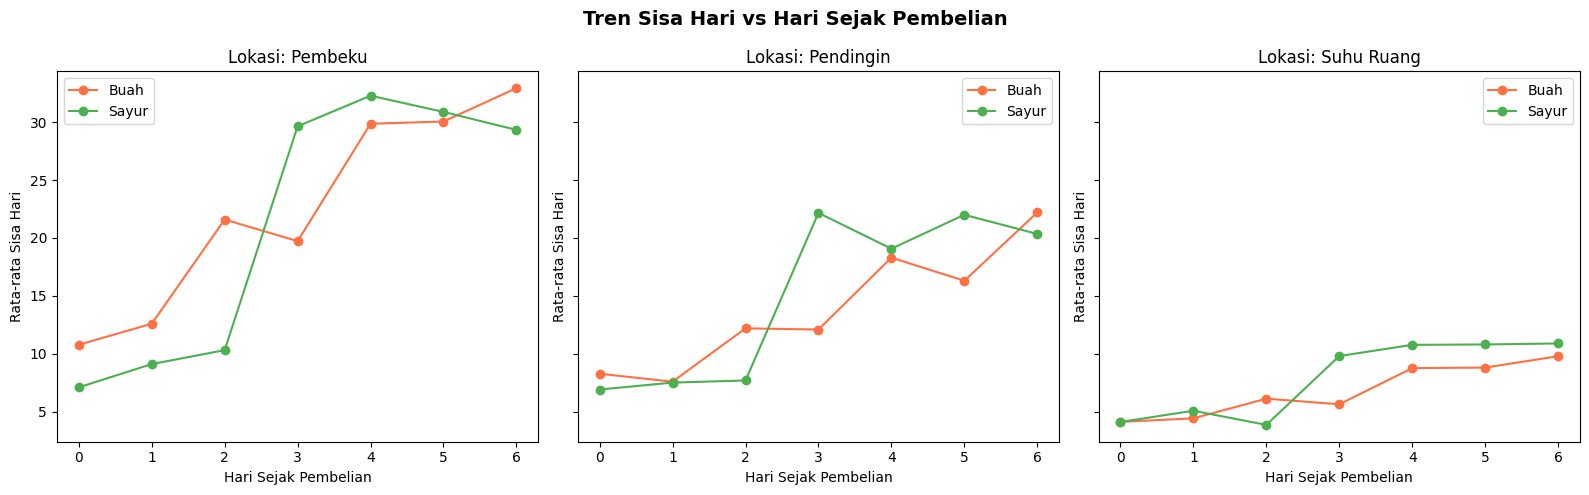

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16,5), sharey=True)

for ax, (loc, group) in zip(
    axes,
    df_clean.groupby('lokasi_penyimpanan')
):
    for item, color in zip(
        ['Buah', 'Sayur'],
        ['#FF7043', '#4CAF50']
    ):
        trend = (group[group['jenis_item'] == item].groupby('hari_sejak_pembelian')['sisa_hari'].mean())
        ax.plot(trend.index, trend.values, marker='o', label=item, color=color)

    ax.set(title=f'Lokasi: {loc}', xlabel='Hari Sejak Pembelian', ylabel='Rata-rata Sisa Hari')

    ax.legend()

plt.suptitle('Tren Sisa Hari vs Hari Sejak Pembelian', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()